<a href="https://colab.research.google.com/github/atikhasan007/Computer-Vision/blob/main/Perform%20Object%20Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Fri Jun 12 18:35:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

In [3]:
from ultralytics import YOLO

In [4]:
!pip install roboflow

In [5]:
!unzip "/content/brain tumor segmentation.yolov11 (2).zip"

Archive:  /content/brain tumor segmentation.yolov11 (2).zip
 extracting: test/images/19 no_jpg.rf.2AVw4zynWyaJ4L3mSUos.jpg  
 extracting: test/images/29 no_jpg.rf.1wO82spBoB21sPSWyWSE.jpg  
 extracting: test/images/Y11_jpg.rf.DwfihayzYYrTo0Sqx9G6.jpg  
 extracting: train/images/22 no_jpg.rf.3FwnfwnR7QfvOJyqv8pA.jpg  
 extracting: test/images/Y7_jpg.rf.UwHWhTNgtXHhi3mDy3pb.jpg  
 extracting: train/images/17 no_jpg.rf.AbgHREfWhWUGsGybxsKB.jpg  
 extracting: train/images/7 no_jpg.rf.0RiiRXaNaaDruUgniPrP.jpg  
 extracting: train/images/33 no_jpg.rf.CXdyTOkdKSvkyaUOPAoc.jpg  
 extracting: train/images/Y24_jpg.rf.5iHUVN2oKn8geFeuD9Wu.jpg  
 extracting: train/images/23 no_jpg.rf.YetoyJ1Yc1lbLkav6d1I.jpg  
 extracting: train/images/Y25_jpg.rf.GwErkAfj7duM5sn6FYtT.jpg  
 extracting: train/images/Y3_jpg.rf.bGb3SrjGlF455X9Ergw3.jpg  
 extracting: train/images/Y32_jpg.rf.FWyg7Cq2nl20kJJhcp2T.jpg  
 extracting: train/images/3 no_jpg.rf.LtKzi11dosmfmDDzmEkx.jpg  
 extracting: train/images/8 no_jpg.r

In [6]:
model = YOLO("yolo11n-seg.pt")

In [7]:
# Train the model
train_results = model.train(
    data="/content/data.yaml", # path to dataset YAML
    epochs=50,#number of epoch
    imgsz=640,# training image size
    device=0, # device to run on ,I.e device=0 or device=0,1,2,3 or device=cpu
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

In [8]:
# show matrix
from IPython.display import Image

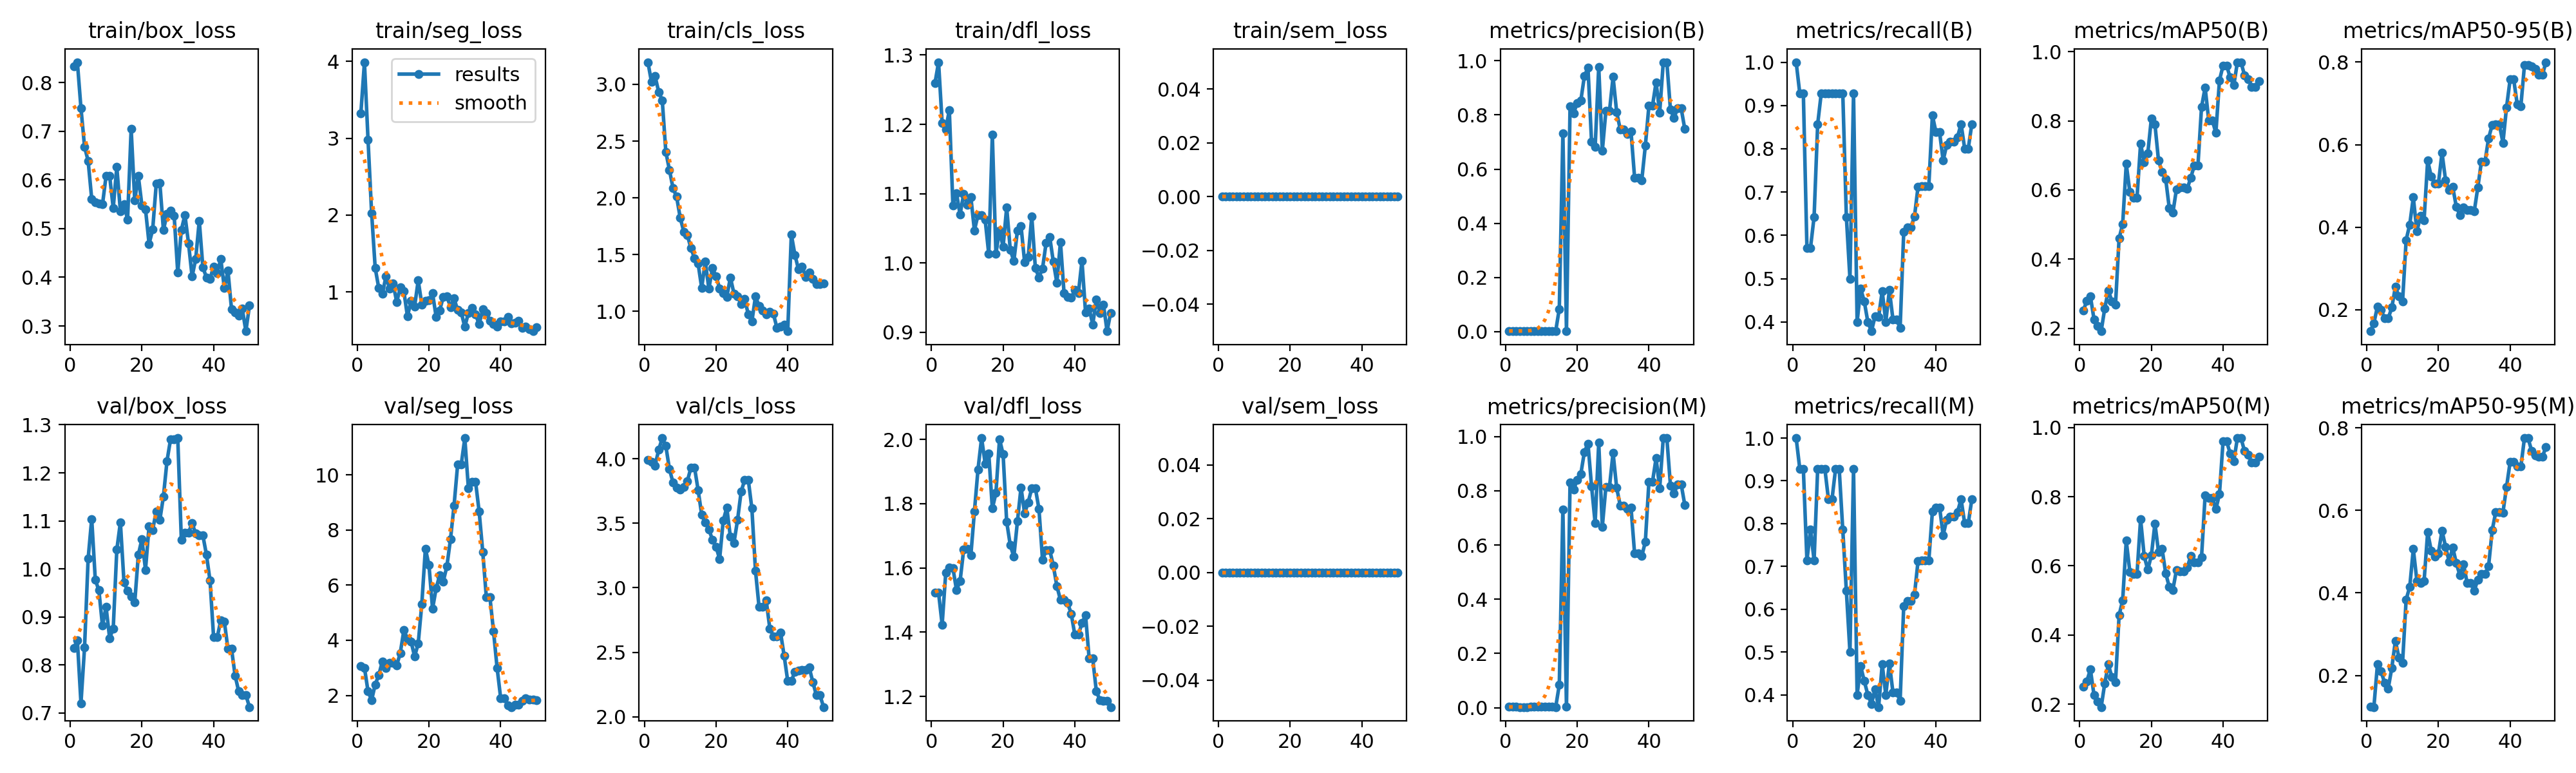

In [10]:
Image("/content/runs/segment/train/results.png",width=600)


image 1/1 /content/test/images/Y2_jpg.rf.52K7tcIqdYjOfDQ5ui1e.jpg: 640x640 (no detections), 9.8ms
Speed: 2.1ms preprocess, 9.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-2


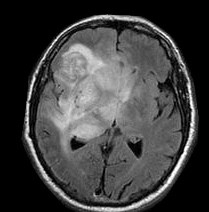

In [15]:
# inference
model = YOLO("/content/runs/segment/train/weights/best.pt")
results = model("/content/test/images/Y2_jpg.rf.52K7tcIqdYjOfDQ5ui1e.jpg",save=True)
results[0].show()


image 1/1 /content/test/images/Y11_jpg.rf.DwfihayzYYrTo0Sqx9G6.jpg: 608x640 1 YES, 62.0ms
Speed: 2.1ms preprocess, 62.0ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)
Results saved to /content/runs/segment/predict-4


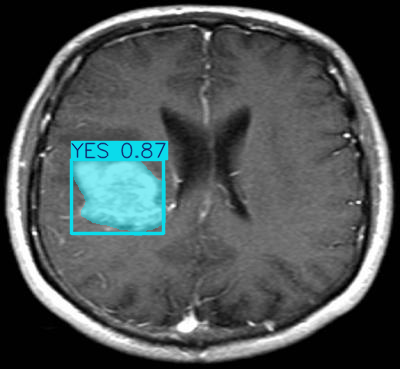

In [17]:
# inference
model = YOLO("/content/runs/segment/train/weights/best.pt")
results = model("/content/test/images/Y11_jpg.rf.DwfihayzYYrTo0Sqx9G6.jpg",save=True)
results[0].show()